# Exercise 5 — Neural Networks

In this exercise, you will understand how a neural network learns by:

* combining inputs with weights
* applying activation functions
* training over epochs
* evaluating performance

## Part A — From Neuron to Prediction

A neuron receives inputs, combines them, and produces an output. `inputs → weighted sum → activation → output`

Mathematically `z = w1*x1 + w2*x2 + b`

Then `output = activation(z)`

In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x1 = 2
x2 = 3

w1 = 0.8
w2 = -0.4
b = 0.5

z = w1*x1 + w2*x2 + b
output = sigmoid(z)

print("z =", z)
print("output =", output)

z = 0.8999999999999999
output = 0.7109495026250039


### Questions

1. What happens if you change w1?
2. What happens if you change w2?
3. What happens if you change b?
4. Why do we need an activation function?

1. The weight of input x1 would be altered. Increase it makes the output more sensitive to x1, while decrease it reduce x1 impact.
2. It also change the influence of x2, this time it has inverse relationship, so increase it will reduce penalty.
3. Increase b raises the total sum z, making it easier for the neuron to produce a higher output. Decreasing b lowers the sum, making the neuron less sensitive.
4. Because Without it, a neural network is will simply do linear math and cannot learn anything complex. Activation functions add the the more sophisticated curves, so it leanrs real world pattern.

## Part B — Activation Functions

In [3]:
x = np.linspace(-5, 5, 200)

print("mean:", np.mean(x))
print("std:", np.std(x))
print("variance:", np.var(x))
print("min:", np.min(x))
print("max:", np.max(x))
print("median:", np.median(x))
print("sum:", np.sum(x))

mean: 1.4210854715202004e-16
std: 2.901221368171633
variance: 8.41708542713568
min: -5.0
max: 5.0
median: 4.440892098500626e-16
sum: 2.842170943040401e-14


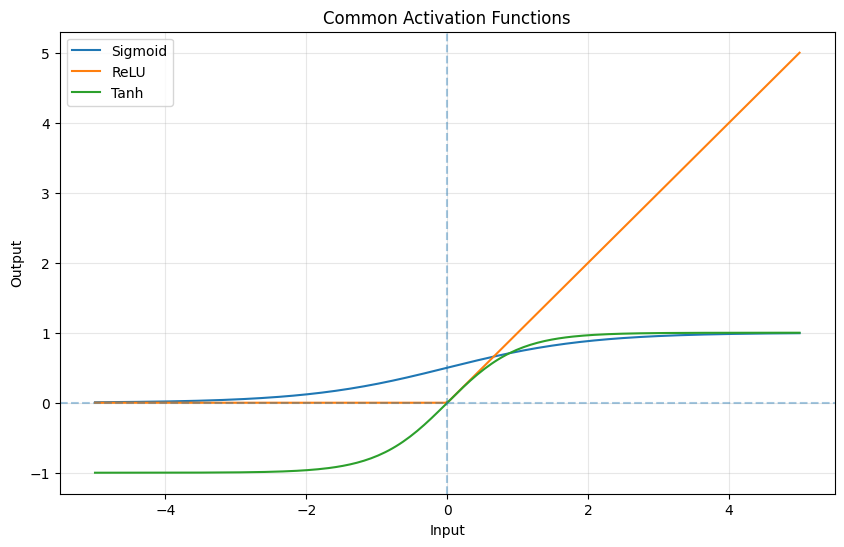

In [4]:
sigmoid_y = 1 / (1 + np.exp(-x))
relu_y = np.maximum(0, x)
tanh_y = np.tanh(x)

plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, tanh_y, label="Tanh")

plt.axhline(0, linestyle="--", alpha=0.4)
plt.axvline(0, linestyle="--", alpha=0.4)

plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Questions

1. Which activation outputs values between 0 and 1?
2. Which activation keeps positive values unchanged?
3. Which activation outputs values between -1 and 1?
4. Which activation would you use for binary classification?

1. Sigmoid outputs values between 0 and 1.
2. ReLU keeps positive values unchanged.
3. Tanh outputs values between -1 and 1.
4. I would use Sigmoid since it maps probability value between 0 and 1.

## Part C — Build a Small Neural Network

We will train a neural network to classify two groups of points.

### Step 1 — Create a Dataset

In [5]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train[:10]

array([[ 0.47898636,  0.96035301],
       [ 2.18078733, -0.15299144],
       [ 1.82978889,  0.17962848],
       [ 0.41314607, -0.29959381],
       [ 1.11157234,  0.28406058],
       [ 0.82466792, -0.03605856],
       [ 0.31021356,  0.82738846],
       [-0.97910539,  0.39922287],
       [-0.69797603,  0.66254685],
       [ 0.10072044,  1.27917835]])

In [6]:
y_train[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0])

Look at the data.
* What type of ML problem is this?
* How many features does the dataset have?

1. This is a binary classification problem
2. The dataset has 2 features: Xtrain output contains 2 numerical values.

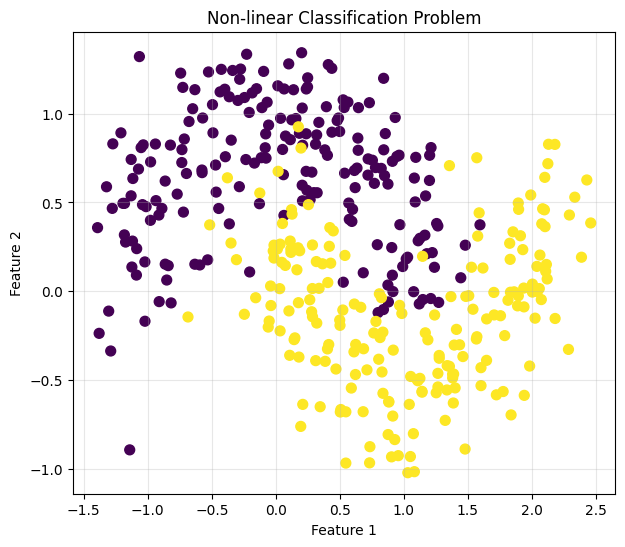

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Non-linear Classification Problem")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

### Why this dataset?

This dataset cannot be easily separated by a straight line.

A neural network can learn a non-linear decision boundary.

Other simulated datasets [here](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators).

## Part D — Train a Neural Network

Check the documentation for [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8083333333333333


## Part E — Visualize the Decision Boundary

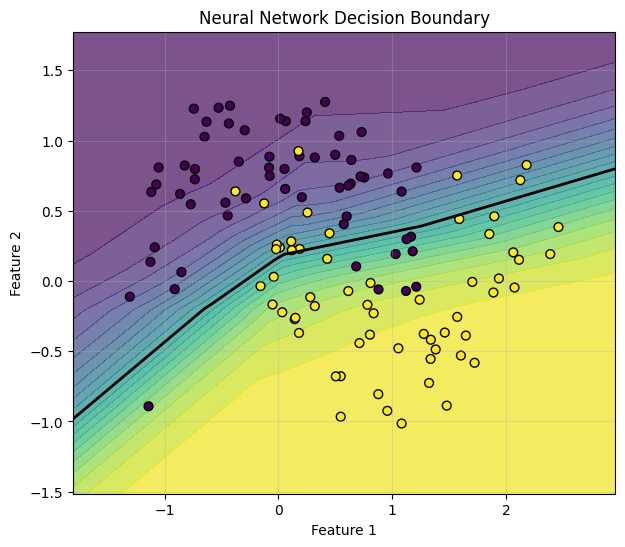

In [9]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1]
    probs = probs.reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    # probability background
    plt.contourf(xx, yy, probs, levels=20, alpha=0.7)

    # decision boundary: probability = 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    # data points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor="k")

    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model, X_test, y_test)

### Questions

1. Is the decision boundary linear or non-linear?
2. Does the model separate the two classes well?
3. Where does it make mistakes?
4. Why is a neural network useful here?

1. The decision is for the most part linear.
2. It seperate quite well, although not completely clear. We can observe some overlaps and misclassifications in complex areas.
3. The mistakes happen in the overlap areas and the curves where these almost straight line boundaries are not accurate enough to make proper classifications.
4. Because it can be ultilized to handle no linear patterns by making more layers and neurons to produce more sophisticated geometric shapes.

## Part F — Training Over Epochs

Neural networks train over multiple epochs.

One epoch means: `one full pass through the training dataset`

### Train with Different Numbers of Epochs

In [10]:
epochs = [10, 50, 200, 1000]

for epoch in epochs:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="relu",
        max_iter=epoch,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Epochs: {epoch} | Accuracy: {acc:.3f}")

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs: 10 | Accuracy: 0.467
Epochs: 50 | Accuracy: 0.683
Epochs: 200 | Accuracy: 0.817
Epochs: 1000 | Accuracy: 0.808


## Part G — Compare Different Network Sizes

In [11]:
architectures = [
    (2,),
    (10,),
    (50,),
    (50, 50)
]

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Architecture: {arch} | Accuracy: {acc:.3f}")

Architecture: (2,) | Accuracy: 0.825
Architecture: (10,) | Accuracy: 0.808


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (50,) | Accuracy: 0.917
Architecture: (50, 50) | Accuracy: 0.933


### Questions

1. `architectures = [(2,), (10,), (50,), (50, 50)]`
What do these numbers mean? 10, (50, 50)?
2. What happens when the network has very few neurons?
3. What happens when the network has many neurons?
4. Which model seems best?
5. Can a neural network overfit?

1. They define hidden layer architecture.
2. They struggle to learn complex patterns which leads to low accuracy performance.
3. They are more flexible to learn complex patterns (non-linear), which increase accuracy.
4. The last one with the highest accuray (0.933) seems best. It has two layers so it performs better than single-layered ones.
5. Yes it can, especially if we make the architecture too big with too many layers.

## Part H — Confusion Matrix

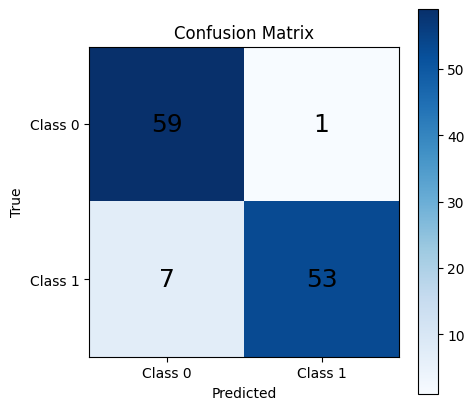

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

### Questions

Try and respond to these questions in a summarized manner.
1. What does a hidden layer do?
2. Why do we need activation functions?
3. What is the role of epochs?
4. What is the role of weights?
5. What happens if the network is too small?
6. What happens if the network is too large?

1. It takes raw input data and convert them to more advanced representations, to the network can see patterns and corelations more easily.
2. They allow networks to learn complex, non-linear boundaries.
3. It is the learning duration, or 1 complete round through the train data.
4. It determines how much importance does a feature have. Adjusting it accordingly will result in better predictions.
5. It will most likely underfits since it can only intepret simple, linear relationships.
6. It will probably overfit since it try to memorize too much detail from the train dataset.

## For more complex coded neural networks, check:

* https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html